<a href="https://colab.research.google.com/github/NataMaru/ML_for_people_tasks/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
df=pd.read_csv('marketing_campaign.csv', sep='\t' )
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
stats = pd.DataFrame({
    'Унікальні значення': df.nunique(),
    'Кількість пропусків': df.isnull().sum(),
    'Доля пропусків (%)': (df.isnull().mean() * 100).round(2)
})

stats.sort_values(by='Доля пропусків (%)', ascending=False)


,Унікальні значення,Кількість пропусків,Доля пропусків (%)
Income,1974,24,1.07
ID,2240,0,0.00
Year_Birth,59,0,0.00
Education,5,0,0.00
Marital_Status,8,0,0.00
Kidhome,3,0,0.00
Teenhome,3,0,0.00
Dt_Customer,663,0,0.00
Recency,100,0,0.00
MntWines,776,0,0.00


Висновок по п. 1
1. Дані мають три типи: int, float та object.
Пропуски містить стовпець Income - планую перевірити на викиди та замінити середнім чи медіаною залежно від наявності аутлаєрів.
2. Дата реєстрації визначена як object, тому для початку зроблю її датою та порахую кількість днів від дати реєстрації, оскільки сама дата нічого не говорить про гостя в задачі кластеризації, а за давністю реєстрації гості розподіляються на старих, нормальних і новачків.
3. Рік народження заміню на вік, оскільки така метрика більш показова для кластерів, ніж рік.
4. Два поля типу object (Education і Marital_Status) нараховують 5 і 8 унікальних значень відповідно, тому їх можна закодувати згідно зі словником і перетворити на числові чи то бінарні колонки.


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

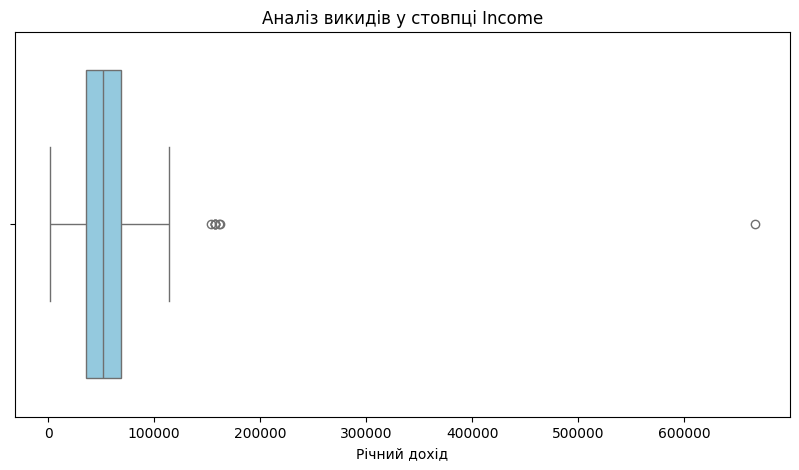

In [5]:
# перевіримо чи містить стовпець Income викиди
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Income'], color='skyblue')

plt.title('Аналіз викидів у стовпці Income')
plt.xlabel('Річний дохід')
plt.show()

In [6]:
# Заповнюємо пропуски в Income медіаною, оскільки вона стабільна до викидів,які видно на графіку вгорі
income_median = df['Income'].median()

df['Income'] = df['Income'].fillna(income_median)

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

#### Education

In [7]:
# Education заміна на числа відопвідно до рівня освіти
education_mapping = {
    'Basic': 1,
    '2n Cycle': 2,
    'Graduation': 3,
    'Master': 4,
    'PhD': 5
}


df['Education'] = df['Education'].map(education_mapping)

####Marital_Status

In [8]:
#Marital_Status
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [9]:
# Об'єднуємо схожі статуси по ознаці клієнт у стосунках чи самотній , оскільки просте кодування від 1 до 8 буде надавати певному статусу більшої важливості ніж інший, а в нашому випадку більш важливо людина в стосунках чи ні
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married': 'Relationship',
    'Together': 'Relationship',
    'Single': 'Single',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

In [10]:
#тепер створимо нові бінарні стопці відповдіності до наявності стосунків
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='MS', dtype=int)

In [11]:
df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,MS_Relationship,MS_Single
0,5524,1957,3,58138.0,0,0,04-09-2012,58,635,88,...,0,0,0,0,0,3,11,1,0,1
1,2174,1954,3,46344.0,1,1,08-03-2014,38,11,1,...,0,0,0,0,0,3,11,0,0,1
2,4141,1965,3,71613.0,0,0,21-08-2013,26,426,49,...,0,0,0,0,0,3,11,0,1,0
3,6182,1984,3,26646.0,1,0,10-02-2014,26,11,4,...,0,0,0,0,0,3,11,0,1,0
4,5324,1981,5,58293.0,1,0,19-01-2014,94,173,43,...,0,0,0,0,0,3,11,0,1,0


####Dt_Customer

In [12]:
#перетворимо на дату та порахуємо кіл-ть днів від дати останньої реєстрації оскільки дані архівні ( якщо дані 'свіжі', то можна рахувати від сьогодні)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
most_recent_date = df['Dt_Customer'].max()
df['Customer_Days'] = (most_recent_date - df['Dt_Customer']).dt.days

print(df[['Dt_Customer', 'Customer_Days']].head())


  Dt_Customer  Customer_Days
0  2012-09-04            663
1  2014-03-08            113
2  2013-08-21            312
3  2014-02-10            139
4  2014-01-19            161


####Year_Birth

In [13]:
#рахуємо вік від максимального в датасеті ( оскільки дані архівні і на сьогодні вік збільшиться на 12 рокі)
max_year = df['Dt_Customer'].dt.year.max()
df['Age'] = max_year - df['Year_Birth']
print(df[['Year_Birth', 'Age']].head())

   Year_Birth  Age
0        1957   57
1        1954   60
2        1965   49
3        1984   30
4        1981   33


In [14]:
df.set_index('ID', inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2240 non-null   int64         
 1   Education            2240 non-null   int64         
 2   Income               2240 non-null   float64       
 3   Kidhome              2240 non-null   int64         
 4   Teenhome             2240 non-null   int64         
 5   Dt_Customer          2240 non-null   datetime64[ns]
 6   Recency              2240 non-null   int64         
 7   MntWines             2240 non-null   int64         
 8   MntFruits            2240 non-null   int64         
 9   MntMeatProducts      2240 non-null   int64         
 10  MntFishProducts      2240 non-null   int64         
 11  MntSweetProducts     2240 non-null   int64         
 12  MntGoldProds         2240 non-null   int64         
 13  NumDealsPurchases    2240 non-null 

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

####Запишіть в змінну X ті дані, які будете кластеризувати.

In [16]:
X=df[[ 'Education', 'Income', 'Kidhome', 'Teenhome',
        'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'MS_Relationship',
       'MS_Single', 'Customer_Days', 'Age']]
X.head()

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,MS_Relationship,MS_Single,Customer_Days,Age
ID,,,,,,,,,,,,,,,,,,,,,
5524,3,58138.0,0,0,58,635,88,546,172,88,...,0,0,0,3,11,1,0,1,663,57
2174,3,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,3,11,0,0,1,113,60
4141,3,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,3,11,0,1,0,312,49
6182,3,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,3,11,0,1,0,139,30
5324,5,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,3,11,0,1,0,161,33


####Побудуйте кластеризацію з KMeans на 3 кластери

In [24]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)

####Обчисліть метрику силуету для цієї кластеризації.

In [25]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

/tmp/ipykernel_14592/2489494537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cluster'] = kmeans.labels_


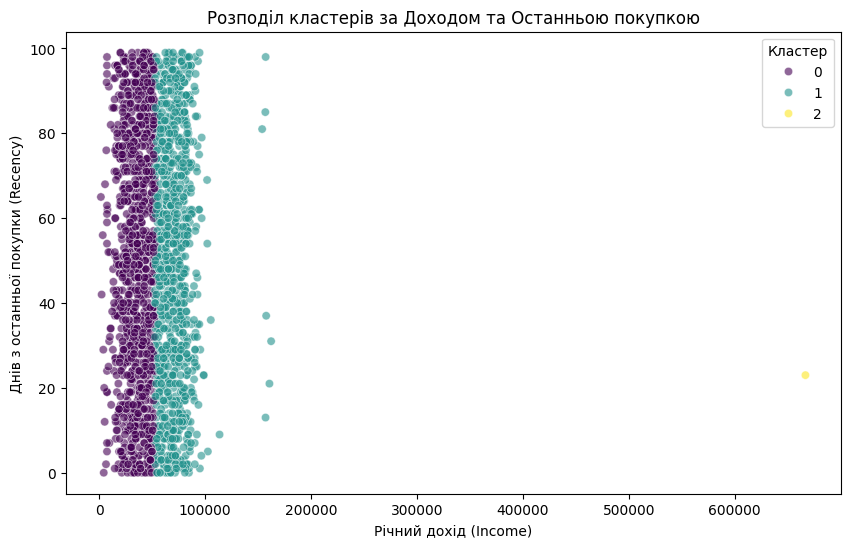

In [26]:
X['Cluster'] = kmeans.labels_

plt.figure(figsize=(10, 6))
sns.scatterplot(data=X, x='Income', y='Recency', hue='Cluster', palette='viridis', alpha=0.6)

plt.title('Розподіл кластерів за Доходом та Останньою покупкою')
plt.xlabel('Річний дохід (Income)')
plt.ylabel('Днів з останньої покупки (Recency)')
plt.legend(title='Кластер')
plt.show()

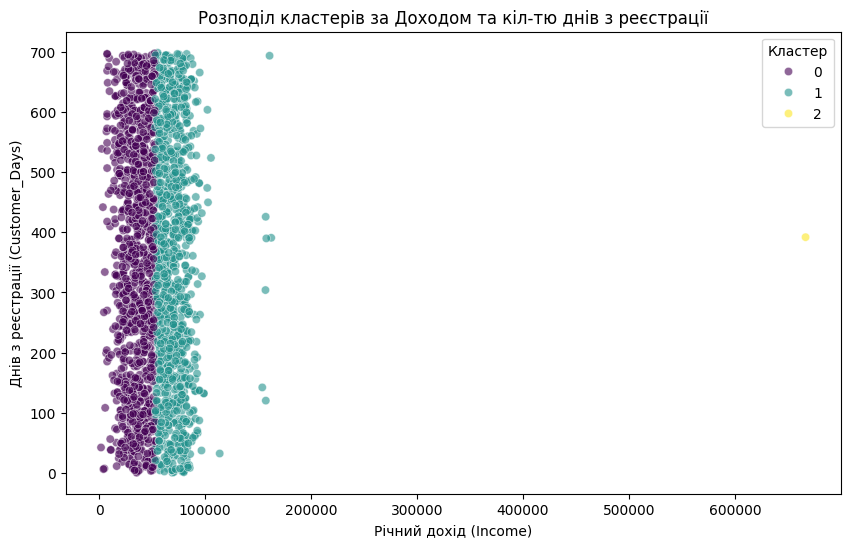

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X, x='Income', y='Customer_Days', hue='Cluster', palette='viridis', alpha=0.6)

plt.title('Розподіл кластерів за Доходом та кіл-тю днів з реєстрації')
plt.xlabel('Річний дохід (Income)')
plt.ylabel('Днів з реєстрації (Customer_Days)')
plt.legend(title='Кластер')
plt.show()

З огляду на графік Recency та Customer_Days не дуже впливали на розподіл по кластерам, бо всі дані розподілились відподвіно до доходу

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled_df.head()

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,MS_Relationship,MS_Single,Customer_Days,Age,Cluster
ID,,,,,,,,,,,,,,,,,,,,,
5524,-0.458383,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,-0.11651,-0.097282,0.0,0.0,2.388846,-1.346874,1.346874,1.531185,0.985345,1.040092
2174,-0.458383,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,-0.11651,-0.097282,0.0,0.0,-0.418612,-1.346874,1.346874,-1.190545,1.235733,-0.958026
4141,-0.458383,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,-0.11651,-0.097282,0.0,0.0,-0.418612,0.742460,-0.742460,-0.205773,0.317643,1.040092
6182,-0.458383,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,-0.11651,-0.097282,0.0,0.0,-0.418612,0.742460,-0.742460,-1.061881,-1.268149,-0.958026
5324,1.533425,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,-0.11651,-0.097282,0.0,0.0,-0.418612,0.742460,-0.742460,-0.953012,-1.017761,1.040092


In [29]:
kmeans_scl = KMeans(n_clusters=3, n_init='auto')
kmeans_scl.fit(X_scaled_df)

labels = kmeans_scl.predict(X_scaled_df)

In [30]:
centroids = kmeans_scl.cluster_centers_
s = metrics.silhouette_score(X_scaled_df, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.16


###Висновок
1. Масштабовані дані показують значно нижчу якість і це пов'язано скоріш за все з тим, що в початкових даних Income має найбільші значення і виступає основним критерієм для визначення кластера, коли дані нормалізовано - значення доходу не є явно виділеними і тому кластери визначаються гірше
2. Проте не варто вірити першому розподілу, оскільки він побудований майже на одному значенні доходц, а такий розподіл можна булоб зробити і без ML.
3. В наступних етапах варто попрацювати з наявними викидами- які є в Income,а також залишити менше фічей ( залишити більш важливі - визначити через центроїди)

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

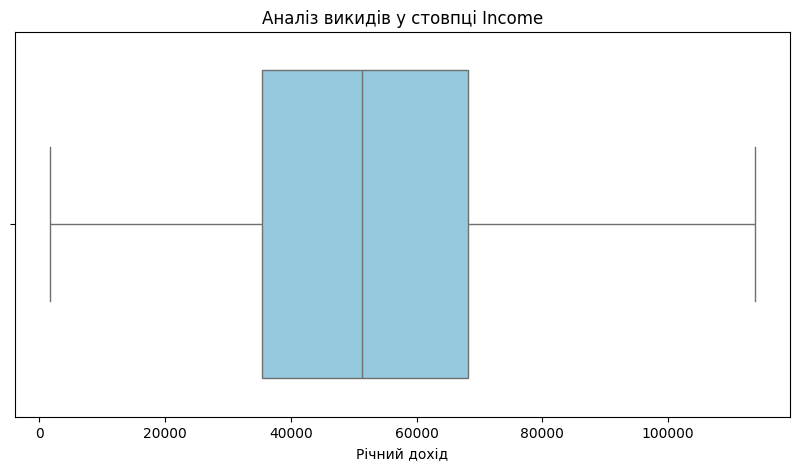

In [31]:
# видалимо викиди в Income
Q1 = X['Income'].quantile(0.25)
Q3 = X['Income'].quantile(0.75)
IQR = Q3 - Q1

X = X[(X['Income'] >= (Q1 - 1.5 * IQR)) & (X['Income'] <= (Q3 + 1.5 * IQR))]

plt.figure(figsize=(10, 5))
sns.boxplot(x=X['Income'], color='skyblue')

plt.title('Аналіз викидів у стовпці Income')
plt.xlabel('Річний дохід')
plt.show()

на графіку вище видно, що наразі викидів немає

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

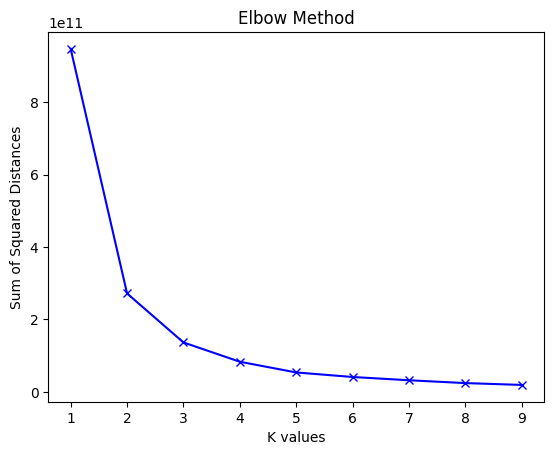

In [32]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [33]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.55


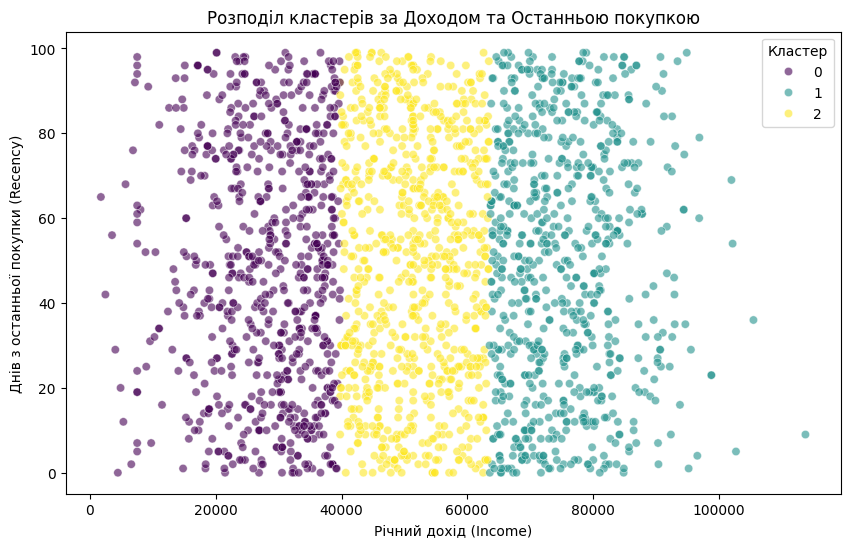

In [34]:
X['Cluster'] = kmeans.labels_

plt.figure(figsize=(10, 6))
sns.scatterplot(data=X, x='Income', y='Recency', hue='Cluster', palette='viridis', alpha=0.6)

plt.title('Розподіл кластерів за Доходом та Останньою покупкою')
plt.xlabel('Річний дохід (Income)')
plt.ylabel('Днів з останньої покупки (Recency)')
plt.legend(title='Кластер')
plt.show()

In [35]:
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

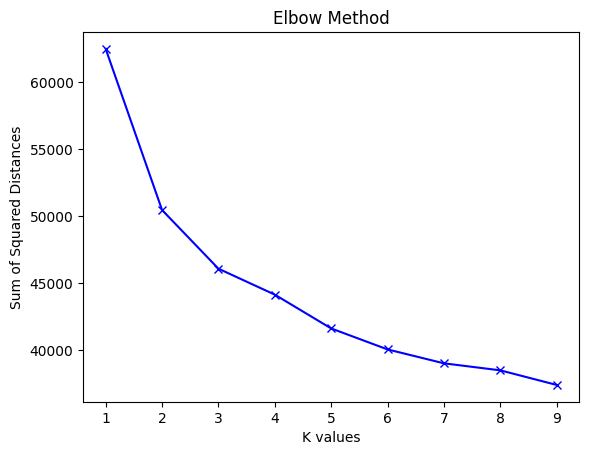

In [36]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [37]:
kmeans_scl = KMeans(n_clusters=2, n_init='auto')
kmeans_scl.fit(X_scaled_df)

labels = kmeans_scl.predict(X_scaled_df)
centroids = kmeans_scl.cluster_centers_
s = metrics.silhouette_score(X_scaled_df, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.21


###Висновок
1. Після обробки Income та застосовуваня методі пошуку кластерів 'Elbow Method' маємо подібні результати. Кіл-ть кластерів 3 і метрика майже така сама - на не масштабованих даних.

2. Кіл-ть кластерів 2 і метрика трохи збільшилась на маштабованих, але якість все одно низька

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

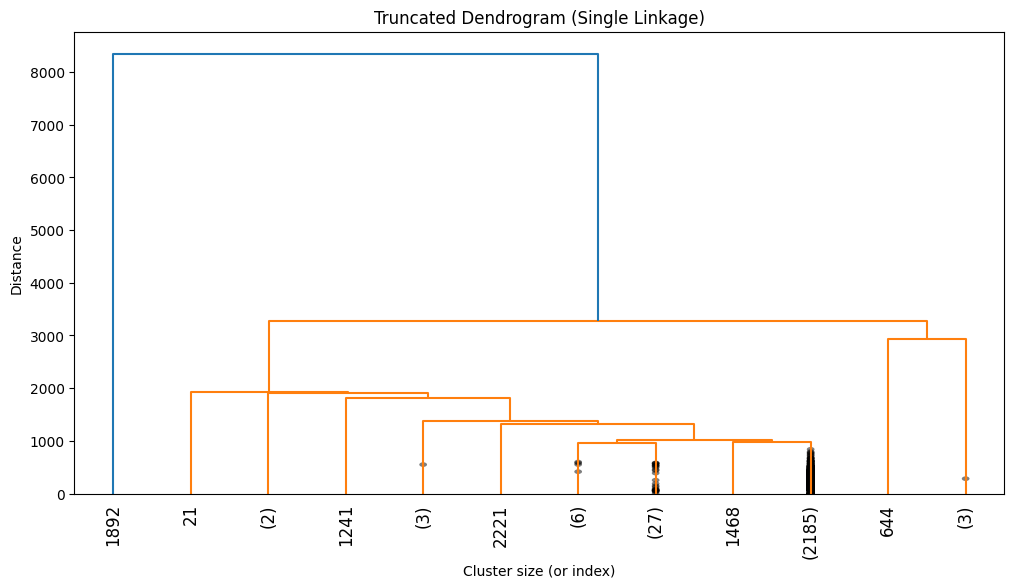

In [39]:
dist_sin = linkage(X, method="single")

plt.figure(figsize=(12, 6))
dendrogram(dist_sin, truncate_mode='lastp', p=12, leaf_rotation=90, show_contracted=True)
plt.title("Truncated Dendrogram (Single Linkage)")
plt.xlabel("Cluster size (or index)")
plt.ylabel("Distance")
plt.show()

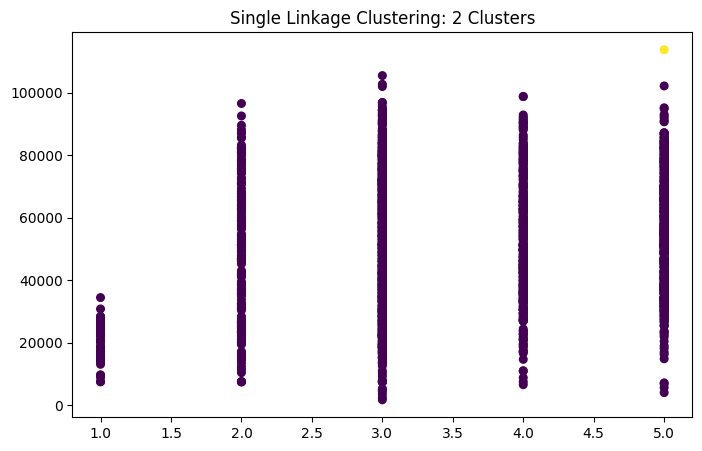

Silhouette Score for 2 clusters: 0.5574


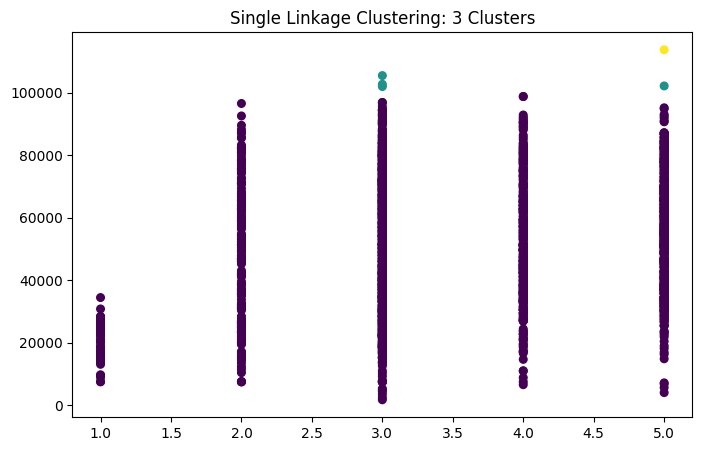

Silhouette Score for 3 clusters: 0.4505


In [44]:
def plot_clusters(X, n_clusters,dist_sin):
    labels = fcluster(dist_sin, t=n_clusters, criterion='maxclust')

    plt.figure(figsize=(8, 5))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis', s=30)
    plt.title(f"Single Linkage Clustering: {n_clusters} Clusters")
    plt.show()

    score = metrics.silhouette_score(X, labels)
    print(f"Silhouette Score for {n_clusters} clusters: {score:.4f}")
    return labels

labels_2 = plot_clusters(X, 2,dist_sin)
labels_3 = plot_clusters(X, 3,dist_sin)

з огляду на дендограму можна виділити два кластери, але один з них скаладється з точки 1892 і тільки тому що вона дуже віддалена і просто 'кричить', що вона не з першого кластера, тому можна зробити висновок що цей метод не є ефективним для наших даних, хоч для двох кластерів метрика Silhouette Score складає 0.5574.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

###method="ward"

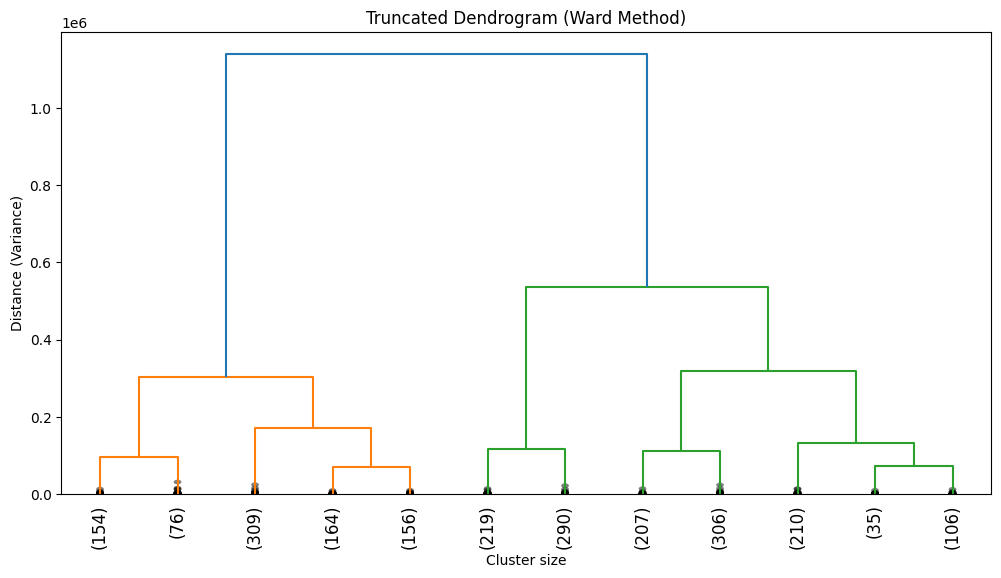

In [43]:
ward = linkage(X, method="ward")


plt.figure(figsize=(12, 6))
dendrogram(
    ward,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=90,
    show_contracted=True
)
plt.title("Truncated Dendrogram (Ward Method)")
plt.xlabel("Cluster size")
plt.ylabel("Distance (Variance)")
plt.show()



на дендограмі чітко видно два кластери, але якщо придивитись, то на середньому рівні зелений кластер чітко ділиться на два і можливо виділити і три кластери.
Візуалізуємо розподіл на два і три кластери і порахуємо відповдіний скор для обох випадків.

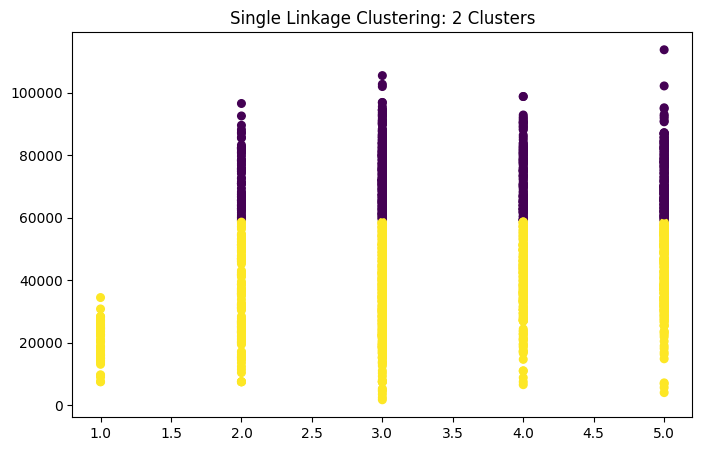

Silhouette Score for 2 clusters: 0.5825


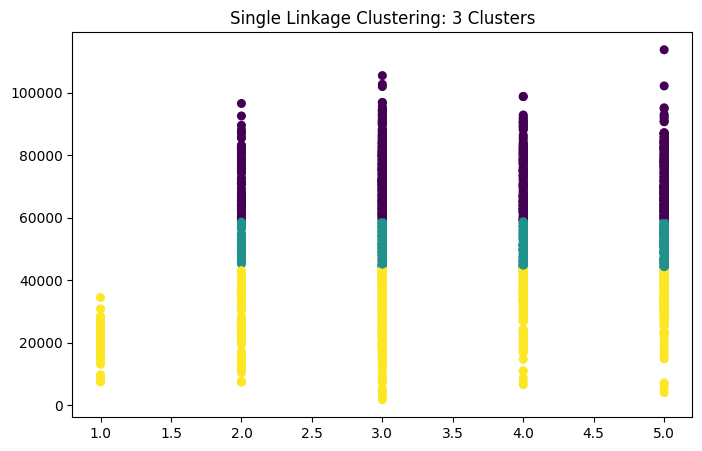

Silhouette Score for 3 clusters: 0.4973


In [45]:
labels_2 = plot_clusters(X, 2,ward)
labels_3 = plot_clusters(X, 3,ward)

При розподілі на три кластери Silhouette Score відчутно знижується з 0.58 до 0.49, тому природнім є розподіл на два кластери

метод "ward" показав кращий результат і тому його можна було б використати і за допомогою нього виділити два кластери та описати їх.
це могло стати початковим етапом в цій задачі ( своєрідним mvp) проте робота з фічами і визначення найбільш впливових могло би дати інший результат - це могло б стати наступним етапом в даній задачі